<a href="https://colab.research.google.com/github/zombie9088/Pytorch_learning/blob/main/tabular_data_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mssmartypants/rice-type-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: swapnanilseal
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mssmartypants/rice-type-classification


100%|██████████| 888k/888k [00:01<00:00, 655kB/s]

In [2]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset,DataLoader
from torchsummary import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
device= 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [4]:
data_df= pd.read_csv("/content/rice-type-classification/riceClassification.csv")
data_df.head(5)


,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [5]:
data_df.dropna(inplace=True)
data_df.drop('id',axis=1,inplace=True)
data_df.head(5)

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [7]:
from sklearn.preprocessing import MinMaxScaler

# Separate features (X) from the target variable (y)
X = data_df.drop('Class', axis=1)
y = data_df['Class']

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

# Convert the scaled features back to a DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Display the first 5 rows of the normalized features
display(X_scaled_df.head())


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation
0,0.262097,0.165901,0.614922,0.149139,0.248903,0.337191,0.544960,0.244209,0.807934,0.032371
1,0.045525,0.005123,0.352934,0.168567,0.051726,0.066336,0.655171,0.036283,0.899898,0.037204
2,0.068418,0.019803,0.366292,0.188069,0.065607,0.098164,0.746848,0.041724,0.950265,0.042222
3,0.071670,0.026591,0.363903,0.213671,0.068573,0.102609,0.795277,0.043795,0.952688,0.049077
4,0.152315,0.100769,0.456247,0.250355,0.145094,0.207586,0.767156,0.106958,0.958906,0.059471


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.3, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.5, random_state=42) # 20% of the training data will be used for validation

In [15]:
X_train.shape, X_test.shape, X_val.shape, y_train.shape, y_test.shape, y_val.shape

((6364, 10), (5456, 10), (6365, 10), (6364,), (5456,), (6365,))

In [16]:
class dataset(Dataset):
  def __init__(self, X, y):
    self.X = torch.tensor(X.values, dtype=torch.float32).to(device)
    self.y = torch.tensor(y.values, dtype=torch.long).to(device)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

In [17]:
training_data= dataset(X_train,y_train)
validataion_data= dataset(X_val,y_val)
testing_data= dataset(X_test,y_test)

In [18]:
train_dataloader= DataLoader(training_data,batch_size=8,shuffle=True)
val_dataloader= DataLoader(validataion_data,batch_size=8,shuffle=True)
test_dataloader= DataLoader(testing_data,batch_size=8,shuffle=True)

In [19]:
for x, y in train_dataloader:
  print(x)
  print('=========')
  print(y)
  break

tensor([[0.8844, 0.8383, 0.7908, 0.7667, 0.8327, 0.9115, 0.4776, 0.6301, 0.7981,
         0.3627],
        [0.4599, 0.7566, 0.3192, 0.9359, 0.4272, 0.5433, 0.7049, 0.4702, 0.6446,
         0.7006],
        [0.7551, 0.6906, 0.7811, 0.6880, 0.7046, 0.8073, 0.3971, 0.5430, 0.8298,
         0.2809],
        [0.4913, 0.7976, 0.3395, 0.9391, 0.4695, 0.5735, 0.1898, 0.5094, 0.6177,
         0.7115],
        [0.5463, 0.5753, 0.5952, 0.7269, 0.5073, 0.6251, 0.5876, 0.4106, 0.8567,
         0.3181],
        [0.5366, 0.8057, 0.3902, 0.9234, 0.5063, 0.6160, 0.4366, 0.5412, 0.6168,
         0.6608],
        [0.8041, 0.7225, 0.8043, 0.6950, 0.7443, 0.8475, 0.4731, 0.5603, 0.8460,
         0.2872],
        [0.9170, 0.8375, 0.8308, 0.7465, 0.8694, 0.9369, 0.4499, 0.6807, 0.7455,
         0.3391]], device='cuda:0')
tensor([0, 1, 0, 1, 0, 1, 0, 0], device='cuda:0')


In [33]:
Hidden_nuerons=10
class MyModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer= nn.Linear(X.shape[1],Hidden_nuerons)
    self.Linear =nn.Linear(Hidden_nuerons,1)
    self.sigmoid=nn.Sigmoid()

  def forward(self,x):
    x= self.input_layer(x)
    x= self.Linear(x)
    x= self.sigmoid(x)
    return x

In [34]:
model= MyModel().to(device)

In [36]:
summary(model, input_size=(X.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             110
            Linear-2                    [-1, 1]              11
           Sigmoid-3                    [-1, 1]               0
Total params: 121
Trainable params: 121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [37]:
criterion= nn.BCELoss()
optimizer= Adam(model.parameters(),lr= 1e-3)

In [38]:
total_train_loss_plot=[]
total_loss_validation_plot=[]
total_acc_train_plot=[]
total_acc_validation_plot=[]

epochs=10
for epoch in range(epochs):
  total_acc_train=0
  total_train_loss=0
  total_loss_validation=0
  total_acc_validation=0

  # Training loop
  model.train() # Set model to training mode
  for data in train_dataloader:
    inputs,labels=data

    optimizer.zero_grad() # Zero the gradients
    outputs = model(inputs) # Forward pass

    # BCELoss expects target to be float and same shape as output
    loss = criterion(outputs, labels.float().unsqueeze(1))

    loss.backward() # Backward pass
    optimizer.step() # Update weights

    total_train_loss += loss.item()

    # Calculate accuracy
    predictions = (outputs > 0.5).float() # Convert probabilities to binary predictions
    total_acc_train += (predictions == labels.float().unsqueeze(1)).sum().item()

  # Validation loop
  model.eval() # Set model to evaluation mode
  with torch.no_grad(): # Disable gradient calculation for validation
    for data in val_dataloader:
      inputs,labels=data

      outputs = model(inputs)
      loss = criterion(outputs, labels.float().unsqueeze(1))

      total_loss_validation += loss.item()

      predictions = (outputs > 0.5).float()
      total_acc_validation += (predictions == labels.float().unsqueeze(1)).sum().item()

  # Calculate average loss and accuracy for the epoch
  avg_train_loss = total_train_loss / len(train_dataloader)
  avg_val_loss = total_loss_validation / len(val_dataloader)

  avg_train_acc = total_acc_train / len(training_data)
  avg_val_acc = total_acc_validation / len(validataion_data)

  # Store for plotting
  total_train_loss_plot.append(avg_train_loss)
  total_loss_validation_plot.append(avg_val_loss)
  total_acc_train_plot.append(avg_train_acc)
  total_acc_validation_plot.append(avg_val_acc)

  # Print epoch results
  print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_acc:.4f} | Val Loss: {avg_val_loss:.4f}, Val Acc: {avg_val_acc:.4f}")

Epoch 1/10 | Train Loss: 0.3940, Train Acc: 0.9043 | Val Loss: 0.1409, Val Acc: 0.9819
Epoch 2/10 | Train Loss: 0.0908, Train Acc: 0.9854 | Val Loss: 0.0654, Val Acc: 0.9832
Epoch 3/10 | Train Loss: 0.0570, Train Acc: 0.9851 | Val Loss: 0.0526, Val Acc: 0.9837
Epoch 4/10 | Train Loss: 0.0489, Train Acc: 0.9849 | Val Loss: 0.0481, Val Acc: 0.9849
Epoch 5/10 | Train Loss: 0.0458, Train Acc: 0.9859 | Val Loss: 0.0465, Val Acc: 0.9848
Epoch 6/10 | Train Loss: 0.0446, Train Acc: 0.9846 | Val Loss: 0.0456, Val Acc: 0.9848
Epoch 7/10 | Train Loss: 0.0435, Train Acc: 0.9854 | Val Loss: 0.0460, Val Acc: 0.9846
Epoch 8/10 | Train Loss: 0.0434, Train Acc: 0.9854 | Val Loss: 0.0453, Val Acc: 0.9843
Epoch 9/10 | Train Loss: 0.0430, Train Acc: 0.9848 | Val Loss: 0.0470, Val Acc: 0.9837
Epoch 10/10 | Train Loss: 0.0429, Train Acc: 0.9855 | Val Loss: 0.0448, Val Acc: 0.9849


In [39]:
model.eval() # Set model to evaluation mode
total_test_loss = 0
total_test_acc = 0
all_predictions = []
all_labels = []

with torch.no_grad(): # Disable gradient calculation for testing
    for inputs, labels in test_dataloader:
        outputs = model(inputs)
        loss = criterion(outputs, labels.float().unsqueeze(1))

        total_test_loss += loss.item()

        predictions = (outputs > 0.5).float()
        total_test_acc += (predictions == labels.float().unsqueeze(1)).sum().item()

        all_predictions.extend(predictions.cpu().numpy().flatten())
        all_labels.extend(labels.cpu().numpy().flatten())

avg_test_loss = total_test_loss / len(test_dataloader)
avg_test_acc = total_test_acc / len(testing_data)

print(f"\nTest Loss: {avg_test_loss:.4f}, Test Accuracy: {avg_test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, all_predictions))
print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_predictions))


Test Loss: 0.0385, Test Accuracy: 0.9868

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      2447
           1       0.99      0.99      0.99      3009

    accuracy                           0.99      5456
   macro avg       0.99      0.99      0.99      5456
weighted avg       0.99      0.99      0.99      5456


Confusion Matrix:
[[2403   44]
 [  28 2981]]


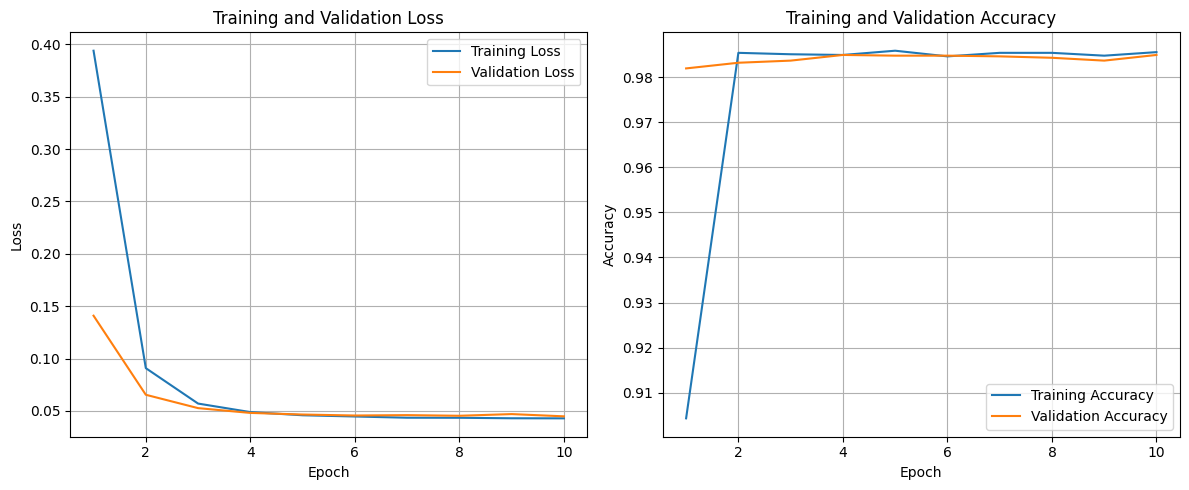

In [40]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 5))

# Plotting Loss
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(epochs_range, total_train_loss_plot, label='Training Loss')
plt.plot(epochs_range, total_loss_validation_plot, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plotting Accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(epochs_range, total_acc_train_plot, label='Training Accuracy')
plt.plot(epochs_range, total_acc_validation_plot, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()